# Lab 8


Name: Umayer Kabir

UTA ID: 1002173764

## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

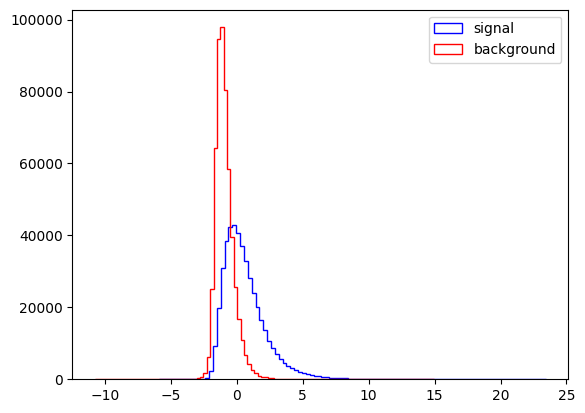

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

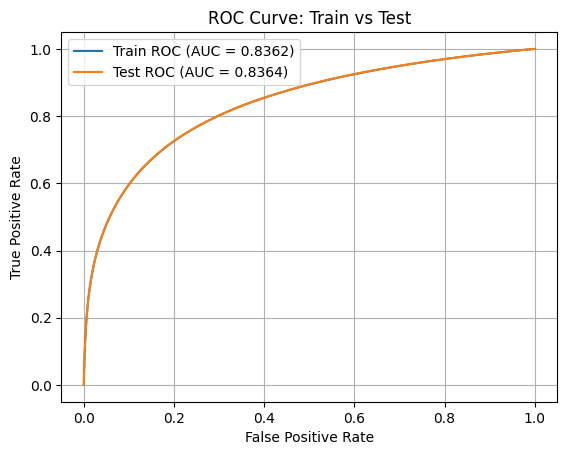

In [7]:
# Part (a)
# Compare ROC curves for training vs testing samples

from sklearn.metrics import roc_curve, auc

# Get decision scores
train_scores = Fisher.decision_function(X_Train)
test_scores  = Fisher.decision_function(X_Test)

# Compute ROC
fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
fpr_test,  tpr_test,  _ = roc_curve(y_Test, test_scores)

# Compute AUC
auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test, tpr_test)

# Plot both on SAME graph
plt.figure()

plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.4f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend()
plt.grid(True)

plt.show()

The ROC curves for the training and testing datasets are very similar, and their AUC values are nearly identical. This indicates that there is no significant bias or overfitting in the model. The classifier generalizes well from the training data to the unseen test data.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

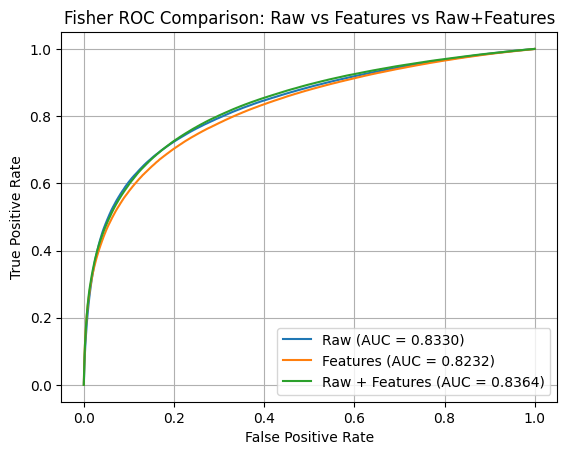

In [8]:
# Part (b)
# Compare Fisher performance using:
# 1) raw variables
# 2) engineered features
# 3) raw + features together

from sklearn.metrics import roc_curve, auc
import sklearn.discriminant_analysis as DA

# In the SUSY dataset:
# first 8 inputs = low-level/raw variables
# remaining 10 inputs = high-level/features

raw_vars = VarNames[1:9]
feature_vars = VarNames[9:]
all_vars = VarNames[1:]

# Store the three input choices in a dictionary so the code stays cleaner
input_sets = {
    "Raw": raw_vars,
    "Features": feature_vars,
    "Raw + Features": all_vars
}

plt.figure()

for name, cols in input_sets.items():
    # make a fresh Fisher classifier for each case
    fisher_model = DA.LinearDiscriminantAnalysis()
    
    # train on the selected columns
    fisher_model.fit(X_Train[cols], y_Train)
    
    # get decision scores on the test set
    scores = fisher_model.decision_function(X_Test[cols])
    
    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)
    
    # plot each curve on the same graph
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher ROC Comparison: Raw vs Features vs Raw+Features")
plt.legend()
plt.grid(True)
plt.show()

The ROC curves show that the Fisher classifier performs best when using both the raw variables and the engineered features together. Using only the raw variables or only the features gives slightly weaker performance. This makes sense because the combined input keeps the most information, which helps the classifier separate signal and background more effectively.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [9]:
# Exercise 4 - Part (a)
# Selecting 3 different classifiers to compare

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize models (keeping parameters simple like a student would)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=50)
}

print("Models initialized.")

Models initialized.


Exercise 4 (a):

For this part, I selected three different classifiers: Logistic Regression, Decision Tree, and Random Forest. Logistic Regression is a simple baseline model, Decision Tree helps capture non-linear relationships, and Random Forest is an ensemble method that generally improves performance by combining multiple trees.

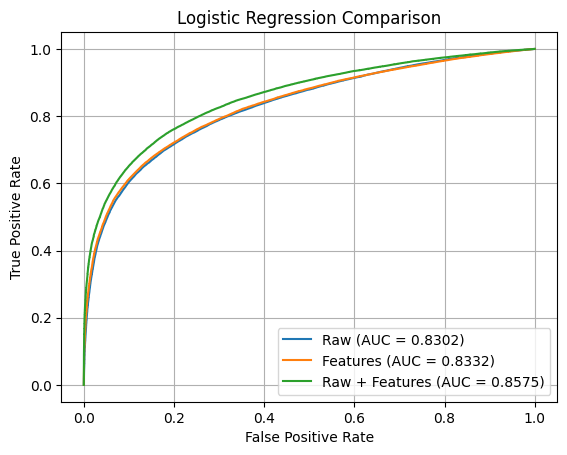

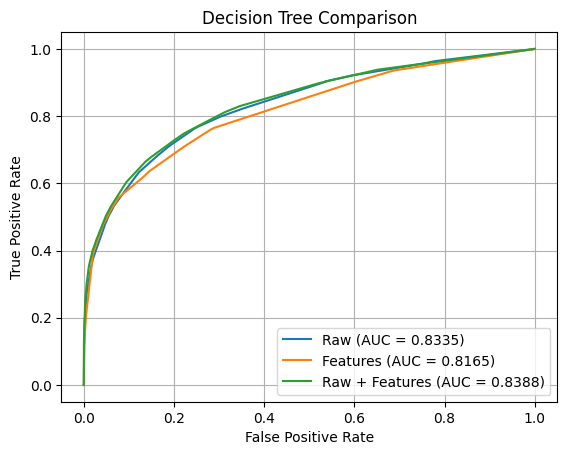

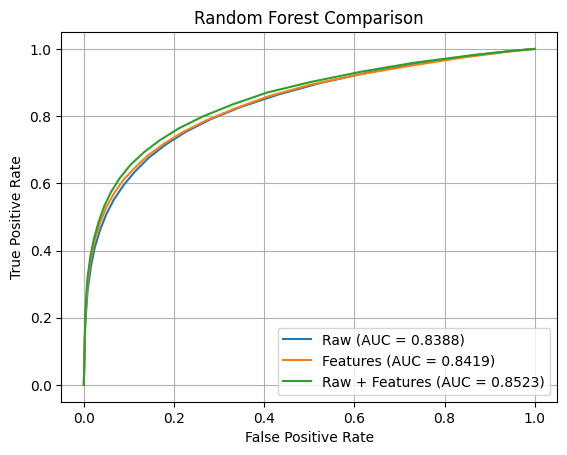

In [10]:
# EXercise 4 - Part (b)

# Smaller sample so the comparison runs faster
sample_size = 100000

X_Train_small = X_Train.iloc[:sample_size]
y_Train_small = y_Train.iloc[:sample_size]

X_Test_small = X_Test.iloc[:sample_size]
y_Test_small = y_Test.iloc[:sample_size]

raw_vars = VarNames[1:9]
feature_vars = VarNames[9:]
all_vars = VarNames[1:]

def compare_classifier(model, name):
    
    input_sets = {
        "Raw": raw_vars,
        "Features": feature_vars,
        "Raw + Features": all_vars
    }
    
    plt.figure()
    
    for label, cols in input_sets.items():
        # Train on the smaller training sample
        model.fit(X_Train_small[cols], y_Train_small)
        
        # Get model scores on the matching smaller test sample
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_Test_small[cols])[:, 1]
        else:
            scores = model.decision_function(X_Test_small[cols])
        
        # ROC must use the matching y values from the same test sample
        fpr, tpr, _ = roc_curve(y_Test_small, scores)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.4f})")
    
    plt.title(f"{name} Comparison")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

# Checking all classifiers
compare_classifier(LogisticRegression(max_iter=1000), "Logistic Regression")
compare_classifier(DecisionTreeClassifier(max_depth=5), "Decision Tree")
compare_classifier(RandomForestClassifier(n_estimators=20), "Random Forest")

In [11]:
# Exercise 4 - Part (c)

# Using Random Forest as the best classifier from part (b)
best_model = RandomForestClassifier(n_estimators=20, random_state=42)

# Train on the smaller sample to keep runtime reasonable
best_model.fit(X_Train_small[all_vars], y_Train_small)

# Get prediction scores for the test sample
scores = best_model.predict_proba(X_Test_small[all_vars])[:, 1]

# Split the scores into true signal and true background
sig_scores = scores[y_Test_small == 1]
bkg_scores = scores[y_Test_small == 0]

# Try many thresholds and compute significance each time
thresholds = np.linspace(scores.min(), scores.max(), 200)

best_sigma = 0
best_threshold = 0
best_NS = 0
best_NB = 0

for threshold in thresholds:
    NS = np.sum(sig_scores >= threshold)
    NB = np.sum(bkg_scores >= threshold)
    
    if NS + NB > 0:
        sigma = NS / np.sqrt(NS + NB)
        
        if sigma > best_sigma:
            best_sigma = sigma
            best_threshold = threshold
            best_NS = NS
            best_NB = NB

print("Best threshold:", round(best_threshold, 4))
print("Ns:", best_NS)
print("Nb:", best_NB)
print("Maximum significance:", round(best_sigma, 4))

Best threshold: 0.402
Ns: 35014
Nb: 11154
Maximum significance: 162.9563


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


Exercise 5 (a)

Precision measures how many events predicted as signal are actually signal. Recall measures how many of the true signal events were correctly found. Accuracy measures the overall fraction of correct predictions. The F1 score combines precision and recall into a single value, so it is useful when we want a balance between them. These metrics are helpful because ROC and AUC show ranking performance, while precision, recall, F1, and accuracy show how well the classifier performs after choosing a decision threshold.

In [12]:
# Exercise 5 - Part (b)

from sklearn.metrics import (
    roc_curve, auc, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix
)
import pandas as pd

# Use the best classifier from Exercise 4
best_model = RandomForestClassifier(n_estimators=20, random_state=42)
best_model.fit(X_Train_small[all_vars], y_Train_small)

# Probability scores for the positive/signal class
scores = best_model.predict_proba(X_Test_small[all_vars])[:, 1]

# ROC and AUC use the continuous scores
roc_fpr, roc_tpr, thresholds = roc_curve(y_Test_small, scores)
roc_auc = auc(roc_fpr, roc_tpr)

# Find the threshold that gives the maximum significance
best_sigma = 0
best_threshold = 0
best_NS = 0
best_NB = 0

for threshold in thresholds:
    preds = (scores >= threshold).astype(int)

    NS = np.sum((preds == 1) & (y_Test_small == 1))
    NB = np.sum((preds == 1) & (y_Test_small == 0))

    if NS + NB > 0:
        sigma = NS / np.sqrt(NS + NB)

        if sigma > best_sigma:
            best_sigma = sigma
            best_threshold = threshold
            best_NS = NS
            best_NB = NB

# Final class predictions using the best threshold
final_preds = (scores >= best_threshold).astype(int)

# Confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_Test_small, final_preds).ravel()

# TPR and FPR from confusion matrix
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

# Other metrics
precision = precision_score(y_Test_small, final_preds)
recall = recall_score(y_Test_small, final_preds)
f1 = f1_score(y_Test_small, final_preds)
accuracy = accuracy_score(y_Test_small, final_preds)

# Nice summary table
results_table = pd.DataFrame({
    "Metric": [
        "TPR",
        "FPR",
        "AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "Accuracy",
        "Max Significance",
        "Best Threshold",
        "Ns",
        "Nb"
    ],
    "Value": [
        round(tpr, 4),
        round(fpr, 4),
        round(roc_auc, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(accuracy, 4),
        round(best_sigma, 4),
        round(best_threshold, 4),
        int(best_NS),
        int(best_NB)
    ]
})

results_table

print(results_table.to_string(index=False))

          Metric      Value
             TPR     0.7654
             FPR     0.2056
             AUC     0.8540
       Precision     0.7584
          Recall     0.7654
        F1 Score     0.7619
        Accuracy     0.7812
Max Significance   162.9563
  Best Threshold     0.4500
              Ns 35014.0000
              Nb 11154.0000
